In [38]:
#Part A:Understanding Dataset
import pandas as pd
agr_def=pd.read_csv("agriculture_yield_dataset.csv",sep=",")
print("Shape: ",agr_def.shape)
print("Columns Name: ",agr_def.columns)
agr_def.head(10)

Shape:  (1500, 8)
Columns Name:  Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='str')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [39]:
print("DataType of each columns:")
print(agr_def.dtypes)

print("\nMissing Value:")
agr_def.isnull().sum()


DataType of each columns:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

Missing Value:


rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Observation:No missing values are present in the dataset.

In [40]:
numeric_df=agr_def.select_dtypes(include='number') 
print(numeric_df.describe())

mean=agr_def.mean(numeric_only=True)
mean_max=mean.max()
feature_name=mean.idxmax()
print("Feature with Max Mean:",feature_name,":",round(mean_max,2))

std=agr_def.std(numeric_only=True)
std_max=std.max()
feat_name=std.idxmax()
print("Feature with Max Standard Deviation:",feat_name,":",round(std_max,2))

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [41]:
#Part B: Exploratory Data Analysis
import plotly.express as px
px.histogram(agr_def,x='rainfall_mm',title='Rainfall_mm')

Observation:
The rainfall values are spread over a wide range indicating good variability in the dataset.
There are no obvious outliers or extreme spikes,suggesting that rainfall values are reasonably balanced across the dataset.

In [42]:
px.histogram(agr_def,x='temperature_c',title='Temperature_c')

Observation:
The temperature values are distributed over a wide range showing good variation in the dataset.
The distribution appears fairly uniform as no single range dominates

In [43]:
px.histogram(agr_def,x='fertilizer_kg',title='Fertilizer_kg')

Observation:
The fertilizer(kg) usage values are spread over a wide range showing good variation in the data.
No significant outliers or extreme spikes are visible ,suggesting a balanced distribution of fertilizer usage

In [44]:
px.histogram(agr_def,x='yield_ton_per_hectare',title='Yield_ton_per_hectare')

Observation:
The distribution is approximately symmetric and bell-shaped 
Most yield values are concentrated between 4-6 tons per hectare,indicating that the majority of farms produce moderate yields.

In [45]:
agr_def['crop_type'].value_counts()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

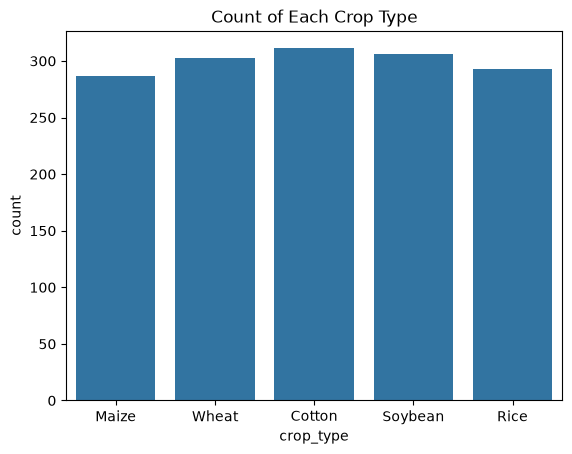

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=agr_def,x='crop_type')
plt.title('Count of Each Crop Type')
plt.show

Observation: Cotton Crop appears to be most frequently grown.

In [47]:
agr_def['soil_type'].value_counts()

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

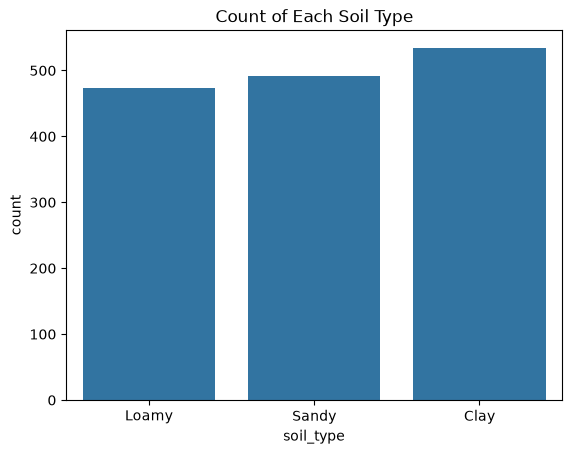

In [48]:
sns.countplot(data=agr_def,x='soil_type')
plt.title("Count of Each Soil Type")
plt.show()

Observation: Clay Soil Type is most commonly used for agriculture.

In [49]:
px.histogram(agr_def,x='yield_ton_per_hectare',title='Yield_ton_per_hectare')

Observation: The distribution is approximately symmetric and resembles a Normal distribution.
No obvious outliers are visible from the histogram.

In [50]:
px.scatter(agr_def,x='rainfall_mm',y='yield_ton_per_hectare',title='Rainfall_mm vs Yield_ton_per_hectare')

In [51]:
px.scatter(agr_def,x='fertilizer_kg',y='yield_ton_per_hectare',title='Fertilizer_kg vs Yield_ton_per_hectare')

Rainfall has a stronger relationship with crop yield. Its plot shows a much clearer, steeper upward slope and a tighter data cluster, meaning changes in water availability predict yield outcomes more reliably than changes in fertilizer usage.

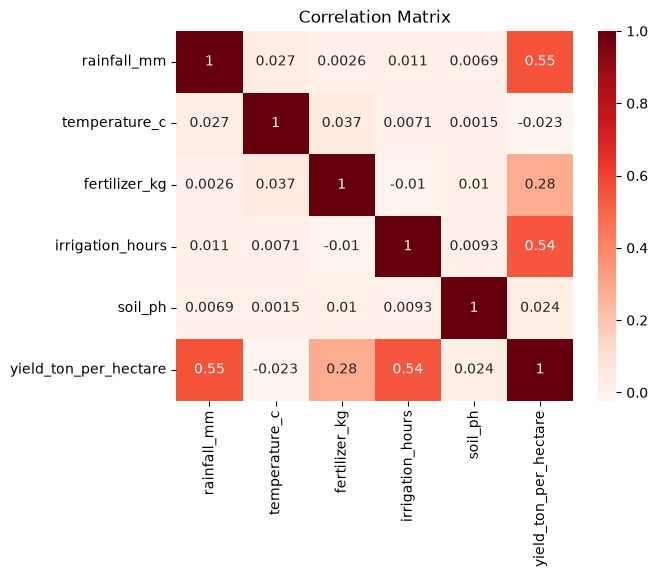

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df=agr_def.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),cmap='Reds',annot=True)
plt.title("Correlation Matrix");

Observation:
The top 3 features which are correlated with crop yield are:
rainfall_mm,irrigation_hours,fertilizer_kg

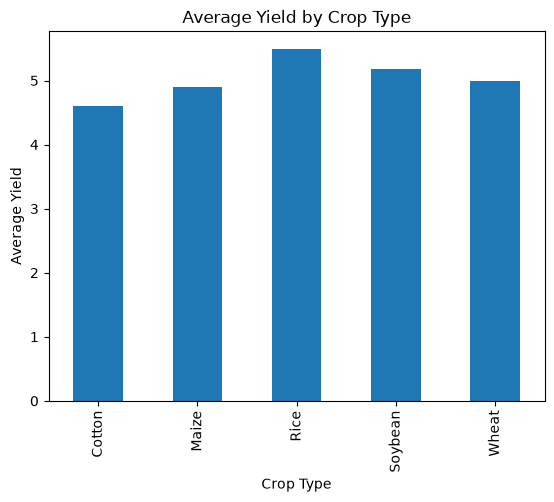

In [53]:
#Grp based Analysis
crop_avg = agr_def.groupby('crop_type')['yield_ton_per_hectare'].mean()
crop_avg.plot(kind='bar')
plt.title('Average Yield by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Average Yield')
plt.show()


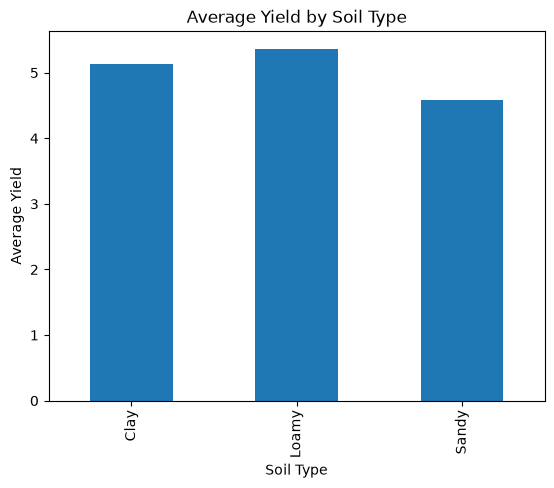

In [54]:
soil_avg = agr_def.groupby('soil_type')['yield_ton_per_hectare'].mean()
soil_avg.plot(kind='bar')
plt.title('Average Yield by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Average Yield')
plt.show()

In [55]:
#Crop Type having highest average yield
print(crop_avg.idxmax(),":",crop_avg.max())

#Soil Type having highest average yield
print(soil_avg.idxmax(),":",soil_avg.max())

Rice : 5.494744027303755
Loamy : 5.366518987341772


In [56]:
#Part C: Data Preparation
categ_col=agr_def.select_dtypes(include='object').columns
print(categ_col)

Index(['crop_type', 'soil_type'], dtype='str')


C:\Users\DELL\AppData\Local\Temp\ipykernel_14996\2834212011.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categ_col=agr_def.select_dtypes(include='object').columns


In [57]:
agri_one_hot=pd.get_dummies(agr_def,columns=['crop_type','soil_type'],drop_first=True)
agri_one_hot.head(5)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [61]:
#Feature Selection
X=agri_one_hot.drop('yield_ton_per_hectare',axis=1)
y=agri_one_hot['yield_ton_per_hectare']


yield_ton_per_hectare is selected as the target variable because it represents the final agricultural output that we want to predict using the other features in the dataset.

In [62]:
#Part D: Machine Learning
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Shape of X_train:",X_train.shape)
print("Shape of X_test:",X_test.shape)
print("Shape of y_train:",y_train.shape)
print("Shape of y_test:",y_test.shape)

Shape of X_train: (1200, 11)
Shape of X_test: (300, 11)
Shape of y_train: (1200,)
Shape of y_test: (300,)


In [ ]:
from sklearn.linear_model import LinearRegression

le = LinearRegression()

le.fit(X_train, y_train)

print("Intercept:", le.intercept_)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': le.coef_
})

print("Coefficients:")
print(coef_df)
 


Intercept: 1.587132027736124
Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object


In [65]:
highest_feature = coef_df.loc[
    coef_df['Coefficient'].idxmax()
]

print(highest_feature)

Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
